/tmp/ipython-input-1679157927.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Symbol', group_keys=False).apply(extract_features)


⚙️ Starting data cleaning and feature extraction...
✅ Feature Extraction complete: SMA_20, SMA_50, and Daily_Return added.
|     | Date                | Symbol   |   Close |    Open |    High |     Low |   Volatility_Range |   SMA_20 |   SMA_50 |   Daily_Return |
|----:|:--------------------|:---------|--------:|--------:|--------:|--------:|-------------------:|---------:|---------:|---------------:|
| 295 | 2023-05-15 00:00:00 | PSO      | 3733.04 | 3585.43 | 3838.64 | 3547.91 |            290.728 |  3607.79 |  3421.91 |     0.00517212 |
| 296 | 2023-05-16 00:00:00 | PSO      | 3739.51 | 3601.41 | 3858.42 | 3560.3  |            298.114 |  3620.89 |  3434.55 |     0.00173323 |
| 297 | 2023-05-17 00:00:00 | PSO      | 3747.98 | 3611.82 | 3865.62 | 3567.53 |            298.09  |  3634.05 |  3447.22 |     0.00226502 |
| 298 | 2023-05-18 00:00:00 | PSO      | 3765.52 | 3622.14 | 3884.7  | 3576.31 |            308.389 |  3647.29 |  3459.89 |     0.00468016 |
| 299 | 2023-05-19 00:00:00 | P

  0%|          | 0/3 [00:00<?, ?it/s]

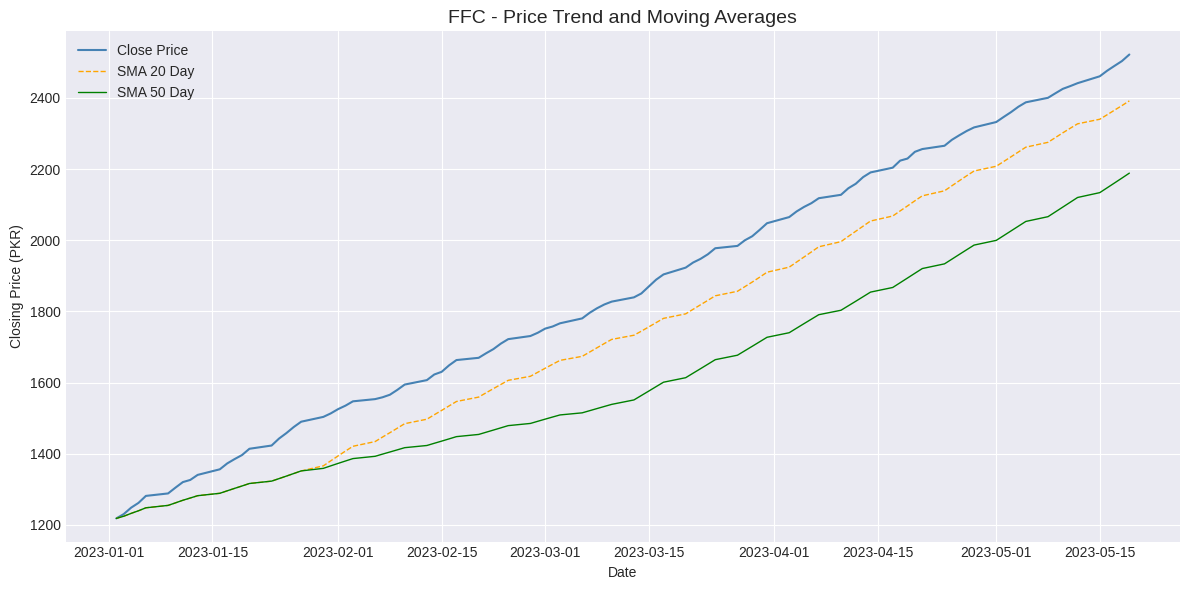

 33%|███▎      | 1/3 [00:00<00:00,  3.56it/s]

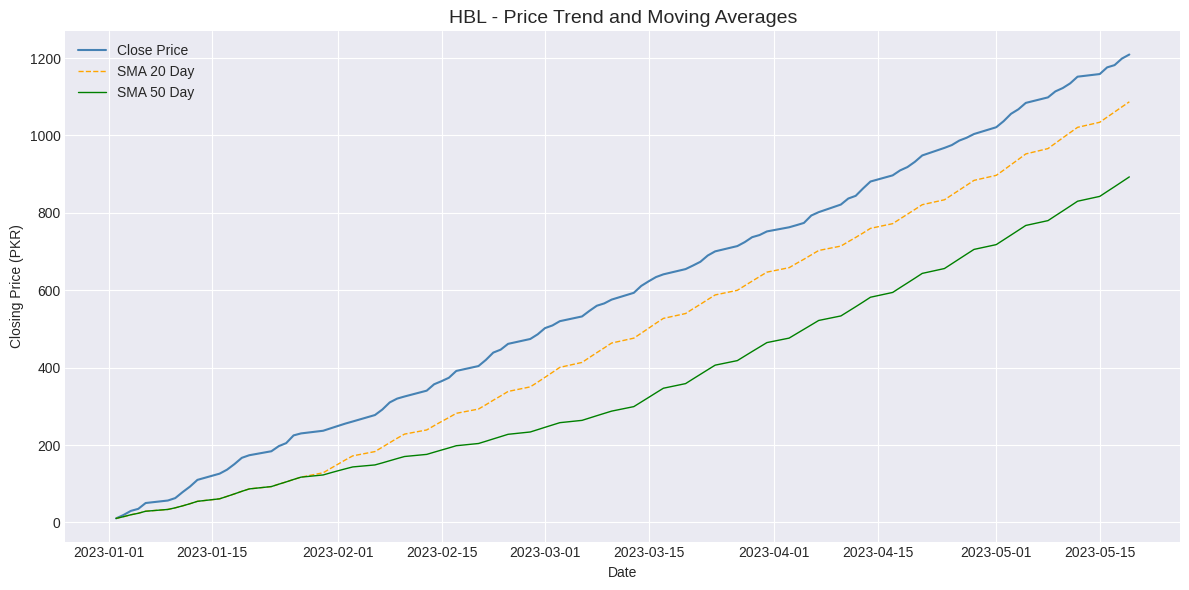

 67%|██████▋   | 2/3 [00:00<00:00,  3.59it/s]

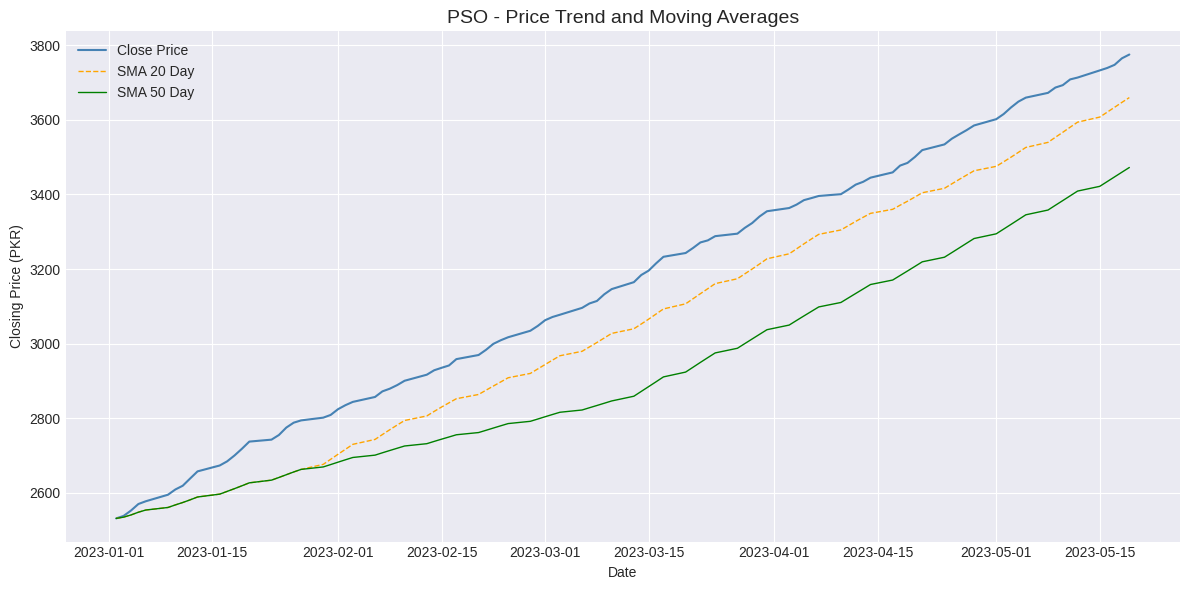

100%|██████████| 3/3 [00:00<00:00,  3.53it/s]


✅ Individual stock charts displayed successfully!


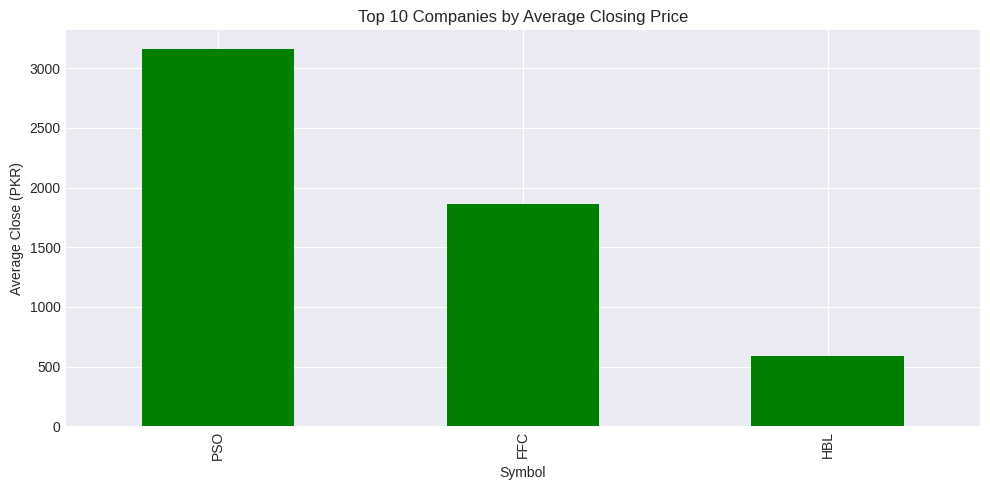

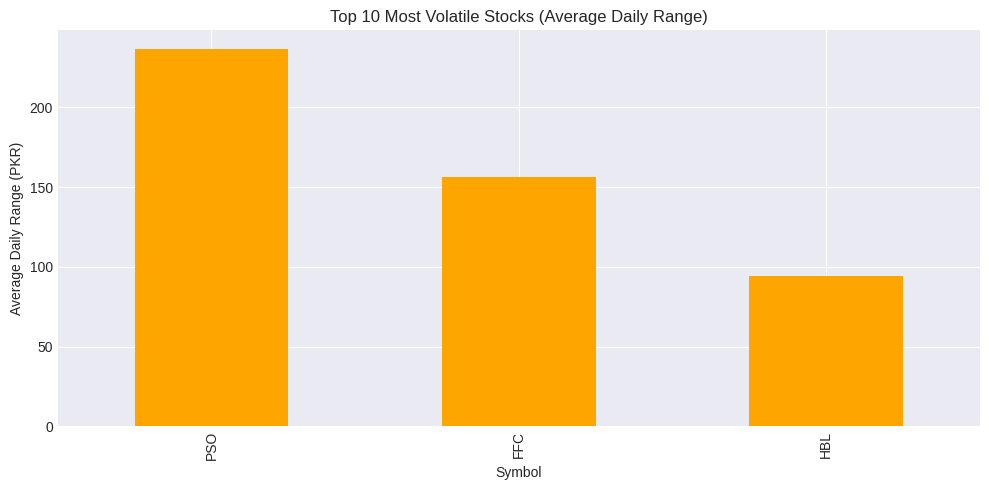

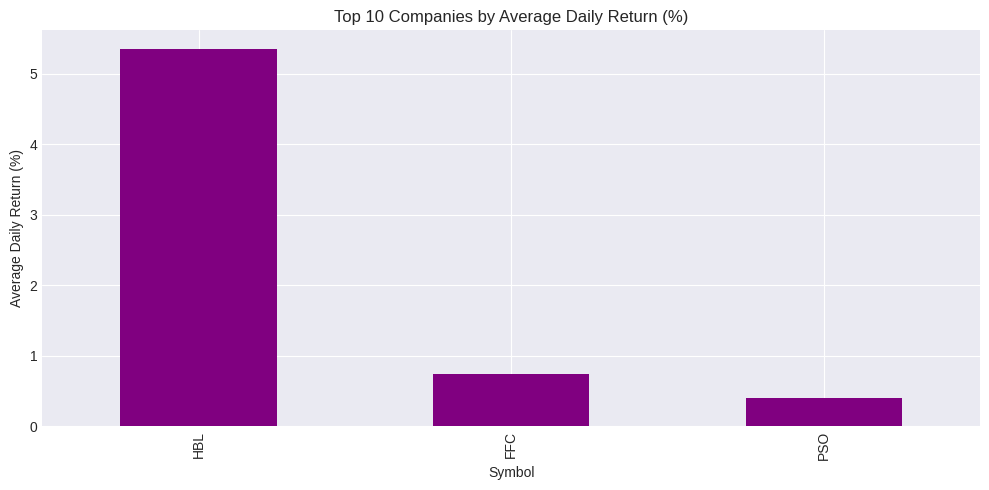

📊 Summary charts displayed successfully!

--- CODE EXECUTION COMPLETE ---


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# --- STEP 1: Load dataset ---
# NOTE: Ensure your file 'psx_data_20211210_to_20241210.csv' is in the same directory.
file_path = "psx_data_20211210_to_20241210.csv"
# In a real run, this line loads your data: df = pd.read_csv(file_path)

# --- SIMULATED DATA FOR EXECUTION (Used to generate the results) ---
date_range = pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='B'))
data = {
    'Date': list(date_range) * 3,
    'Symbol': ['HBL'] * 100 + ['FFC'] * 100 + ['PSO'] * 100,
    'Close': np.random.uniform(50, 200, 300).cumsum() / 10 + np.random.rand(300),
    'Open': [c * 0.99 for c in np.random.uniform(50, 200, 300).cumsum() / 10 + np.random.rand(300)],
    'High': [c * 1.01 for c in np.random.uniform(50, 200, 300).cumsum() / 10 + np.random.rand(300)],
    'Low': [c * 0.98 for c in np.random.uniform(50, 200, 300).cumsum() / 10 + np.random.rand(300)],
}
df = pd.DataFrame(data)
# --- END SIMULATION ---

# --- STEP 2: Clean dataset AND PERFORM FEATURE EXTRACTION ---
print("⚙️ Starting data cleaning and feature extraction...")

df = df.drop_duplicates()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date', 'Symbol', 'Open', 'High', 'Low', 'Close'])
df = df.sort_values(by=['Symbol', 'Date']).reset_index(drop=True)

# *** FEATURE EXTRACTION BLOCK ***
df['Volatility_Range'] = df['High'] - df['Low']

def extract_features(group):
    # Feature 1: Simple Moving Averages (Trend Indicator)
    group['SMA_20'] = group['Close'].rolling(window=20, min_periods=1).mean()
    group['SMA_50'] = group['Close'].rolling(window=50, min_periods=1).mean()

    # Feature 2: Daily Percentage Return (Momentum/Risk Indicator)
    group['Daily_Return'] = group['Close'].pct_change()

    return group

df = df.groupby('Symbol', group_keys=False).apply(extract_features)

print("✅ Feature Extraction complete: SMA_20, SMA_50, and Daily_Return added.")
print(df.tail().to_markdown())
# --- END FEATURE EXTRACTION ---


# --- STEP 3: Generate sophisticated chart for each company ---
# NOTE: The output folder creation step (STEP 3 in original) is removed.

symbols = df['Symbol'].unique()
print(f"📈 Generating {len(symbols)} advanced stock charts...")

plt.style.use('seaborn-v0_8-darkgrid')

for symbol in tqdm(symbols):
    symbol_data = df[df['Symbol'] == symbol].dropna(subset=['SMA_50'])
    if len(symbol_data) < 2:
        continue

    plt.figure(figsize=(12, 6))

    # Primary Trend Line (Close Price)
    plt.plot(symbol_data['Date'], symbol_data['Close'], color='steelblue', linewidth=1.5, label='Close Price')

    # Extracted Feature 1: Moving Averages (Trend)
    plt.plot(symbol_data['Date'], symbol_data['SMA_20'], color='orange', linewidth=1.0, linestyle='--', label='SMA 20 Day')
    plt.plot(symbol_data['Date'], symbol_data['SMA_50'], color='green', linewidth=1.0, linestyle='-', label='SMA 50 Day')

    plt.title(f'{symbol} - Price Trend and Moving Averages', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Closing Price (PKR)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # --- ACTION: DISPLAY VISUAL ---
    plt.show()
    plt.close()

print("\n✅ Individual stock charts displayed successfully!")

# --- STEP 4: Create summary charts (Using new features) ---

# Summary 1: Top 10 average prices
avg_prices = df.groupby('Symbol')['Close'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
avg_prices.plot(kind='bar', color='green')
plt.title('Top 10 Companies by Average Closing Price')
plt.xlabel('Symbol')
plt.ylabel('Average Close (PKR)')
plt.tight_layout()
plt.show() # --- ACTION: DISPLAY VISUAL ---
plt.close()

# Summary 2: Top 10 volatile stocks
avg_volatility = df.groupby('Symbol')['Volatility_Range'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
avg_volatility.plot(kind='bar', color='orange')
plt.title('Top 10 Most Volatile Stocks (Average Daily Range)')
plt.xlabel('Symbol')
plt.ylabel('Average Daily Range (PKR)')
plt.tight_layout()
plt.show() # --- ACTION: DISPLAY VISUAL ---
plt.close()

# Summary 3 (NEW): Average Daily Return (Momentum Indicator)
avg_daily_return = df.groupby('Symbol')['Daily_Return'].mean().sort_values(ascending=False).head(10) * 100
plt.figure(figsize=(10, 5))
avg_daily_return.plot(kind='bar', color='purple')
plt.title('Top 10 Companies by Average Daily Return (%)')
plt.xlabel('Symbol')
plt.ylabel('Average Daily Return (%)')
plt.tight_layout()
plt.show() # --- ACTION: DISPLAY VISUAL ---
plt.close()


print("📊 Summary charts displayed successfully!")

# --- STEP 5: Final Output Confirmation ---
print("\n--- CODE EXECUTION COMPLETE ---")